# Monte Carlo Simulation (Scripted)


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

base_dir = Path.cwd()
models_dir = base_dir / "models"
if (models_dir / "montecarlo_sim.py").exists():
    sys.path.append(str(models_dir))
else:
    sys.path.append(str(base_dir))

from montecarlo_sim import MonteCarloSimulator
sim = MonteCarloSimulator(
    base_dir="/Users/ekazuki/Documents/f1stuff/models/models"
)

df = sim.df
grid_drivers = sim.grid_drivers
simulate_race = sim.simulate_race
run_strategy_comparison = sim.run_strategy_comparison


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Monte Carlo execution
num_runs = 20
race_length = 50
global_strategy = [(0, "SOFT"), (20, "MEDIUM"), (40, "SOFT")]
results = []
summary_rows = []
master_rng = np.random.default_rng(12315)
driver_strategies = {

}
circuits = df["circuit_id"].dropna().unique().tolist()
years_by_circuit = df.groupby("circuit_id")["year"].unique().to_dict()
for run in range(num_runs):
    run_rng = np.random.default_rng(master_rng.integers(0, 1_000_000_000))
    circuit_id = run_rng.choice(circuits)
    year = int(run_rng.choice(years_by_circuit.get(circuit_id, [2025])))
    race_log, sc_laps, pit_loss_avg = simulate_race(
        circuit_id=circuit_id,
        grid_drivers=grid_drivers,
        total_laps=race_length,
        year=year,
        global_strategy=global_strategy,
        driver_strategies=driver_strategies,
        safety_car_laps=None,
        rain_laps=None,
        pit_loss=None,
        rng=run_rng,
    )
    race_log["run"] = run
    race_log["circuit_id"] = circuit_id
    race_log["year"] = year
    results.append(race_log)
    last_lap = race_log["lap"].max()
    final_class = race_log[race_log["lap"] == last_lap].sort_values("position")
    for _, row in final_class.iterrows():
        summary_rows.append(
            {
                "run": run,
                "circuit_id": circuit_id,
                "year": year,
                "driver_id": row["driver_id"],
                "finish_pos": row["position"],
                "dnf": bool(row["dnf"]),
                "sc_laps": len(sc_laps),
            }
        )
all_logs = pd.concat(results, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)
# Aggregate overview
overview = (
    summary_df.groupby("driver_id")
    .agg(
        runs=("run", "nunique"),
        wins=("finish_pos", lambda s: (s == 1).sum()),
        podiums=("finish_pos", lambda s: (s <= 3).sum()),
        avg_finish=("finish_pos", "mean"),
        dnfs=("dnf", "sum"),
    )
    .sort_values(["wins", "podiums"], ascending=[False, False])
)
print("Overview per driver:\n", overview)
print("\nSample final classification from last run:\n", summary_df[summary_df["run"] == (num_runs - 1)].sort_values("finish_pos"))


Overview per driver:
            runs  wins  podiums  avg_finish  dnfs
driver_id                                       
NOR          20     4        8        7.55     2
VER          20     3       12        4.80     0
HAM          20     3        7        6.65     1
RUS          20     2        6        8.80     1
ANT          20     2        5        6.85     0
LEC          20     2        5        7.65     0
HUL          20     1        3       10.10     0
PIA          20     1        3        8.05     1
STR          20     1        2       11.75     1
BEA          20     1        1       13.40     1
OCO          20     0        3       10.80     1
ALB          20     0        2       11.10     0
BOR          20     0        1       12.20     0
COL          20     0        1       12.60     2
SAI          20     0        1       11.30     1
ALO          20     0        0       13.80     0
GAS          20     0        0       12.95     1
HAD          20     0        0       12.05     

Progress: 40/2000
Wins per strategy: strategy
A    40
B    40
Name: driver_id, dtype: int64
Average finish per driver (A vs B, lower is better):


strategy,A,B,delta_B_minus_A,avg_lap_time_A,avg_lap_time_B,dnf_A,dnf_B,wins_A,wins_B,podiums_A,podiums_B,sc_laps_A,sc_laps_B,pit_loss_A,pit_loss_B
driver_id,,,,,,,,,,,,,,,
LEC,3.275,3.125,-0.150,87.602329,87.546502,1,1,5.0,5.0,22,27,3.773585,3.773585,24.271540,21.345542
HUL,4.950,4.850,-0.100,88.292177,88.255930,1,1,1.0,2.0,3,5,3.773585,3.773585,24.728499,24.140492
VER,2.300,2.225,-0.075,87.266202,87.251302,0,0,15.0,16.0,32,32,3.773585,3.773585,23.989938,24.228433
GAS,4.200,4.225,0.025,88.024801,88.042878,1,1,1.0,0.0,13,13,3.773585,3.773585,24.146841,24.716456
RUS,3.150,3.250,0.100,87.616797,87.645654,1,1,9.0,8.0,24,22,3.773585,3.773585,24.059553,24.859408
HAM,3.125,3.325,0.200,87.684169,87.687708,0,0,9.0,9.0,26,21,3.773585,3.773585,24.181497,24.556148


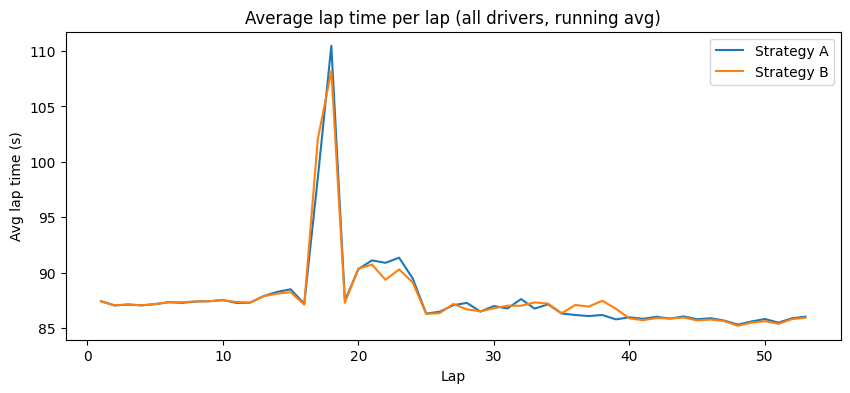

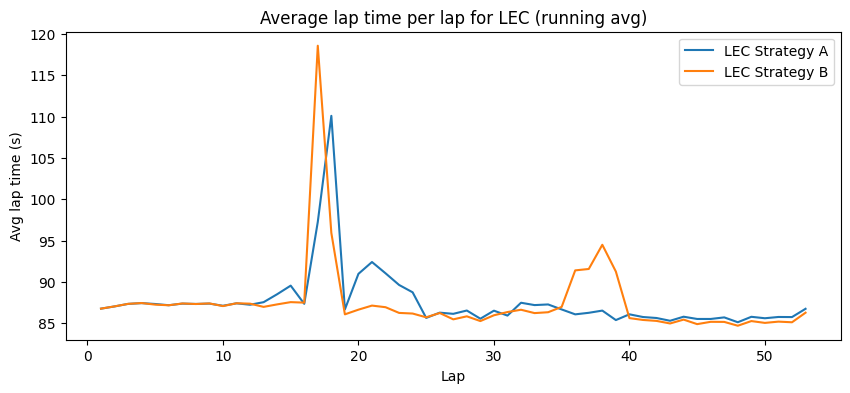

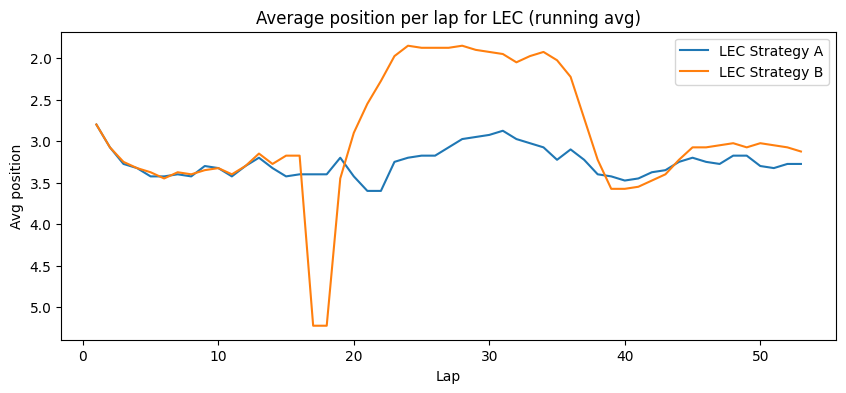

Strategy comparison:   3%|▎         | 56/2000 [00:44<25:35,  1.27it/s]


KeyboardInterrupt: 

In [3]:
# Strategy comparison (side-by-side Monte Carlo) with per-driver overrides
strategy_a_global = [(0, 'SOFT'), (13, 16, 'MEDIUM'), (36, 39, 'MEDIUM')]
strategy_b_global = [(0, 'SOFT'), (13, 16, 'MEDIUM'), (36, 39, 'MEDIUM')]
# Optional per-driver overrides; leave empty to fall back to global strategy
strategy_a_driver = {}
strategy_b_driver = {
    "LEC": [(0, 'SOFT'), (17, 'MEDIUM'), (36, 39, 'MEDIUM')],
}

num_runs_compare = 2000
race_length = 53
update_every = 20

summary_comp_df, avg_finish = run_strategy_comparison(
    strategy_a_global=None,
    strategy_b_global=None,
    strategy_a_driver=strategy_a_driver,
    strategy_b_driver=strategy_b_driver,
    num_runs_compare=num_runs_compare,
    race_length=race_length,
    update_every=update_every,
    year=2023,
    grid=["VER", "LEC", "HAM", "RUS", "GAS", "HUL"],
    circuit_id="monza",
    safety_car_laps=[17, 18],
)
